In [1]:
from google.colab import drive, files
import os, time

drive.mount('/content/drive', force_remount=False)
os.makedirs('/content/drive/MyDrive/Assignment4', exist_ok=True)
print("✅ Drive mounted. Now upload English-Hindi.tsv:")
files.upload()
print("✅ File ready at /content/English-Hindi.tsv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted. Now upload English-Hindi.tsv:


Saving English-Hindi.tsv to English-Hindi (1).tsv
✅ File ready at /content/English-Hindi.tsv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('English-Hindi.tsv', sep='\t', header=None, names=["id1", "en", "id2", "hi"])
df.sample(5)


,id1,en,id2,hi
310,22850,We are against war.,451241,हम जंग के ख़िलाफ़ हैं।
6991,3402556,Tom is probably wrong.,3638921,टॉम शायद गलत है।
2467,276124,I heard someone knocking.,455625,मुझे किसी के खटखटाने की आवाज़ सुनाई दी।
9425,3740410,Are you back from Japan?,4071175,तुम जापान से लौट आए हो क्या?
9025,314143,She made tea for me.,4061065,उसने मेरे लिये चाय बनाई।


In [3]:
df = df[["en", "hi"]]
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()


,en,hi
0,Muiriel is 20 now.,म्यूरियल अब बीस साल की हो गई है।
1,Muiriel is 20 now.,म्यूरियल अब बीस साल की है।
2,Education in this world disappoints me.,मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।
3,That won't happen.,वैसा नहीं होगा।
4,I miss you.,मुझें तुम्हारी याद आ रही है।


Total pairs: 13186

English Sentence Length Stats:
count    13186.000000
mean         5.607614
std          2.676713
min          1.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         53.000000
Name: en_len, dtype: float64

Hindi Sentence Length Stats:
count    13186.000000
mean         6.277719
std          2.999823
min          1.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         57.000000
Name: hi_len, dtype: float64


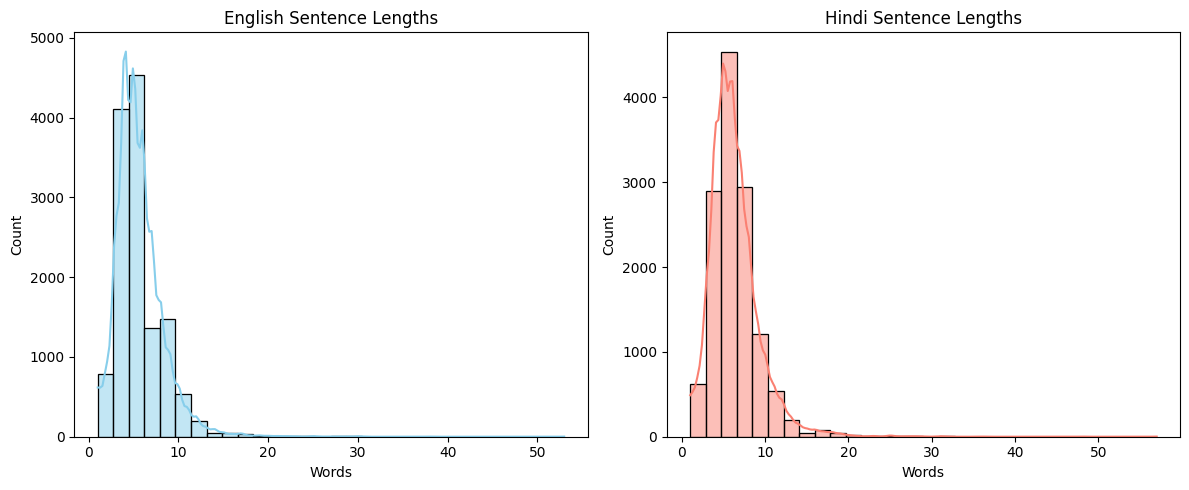

EN: Muiriel is 20 now.
HI: म्यूरियल अब बीस साल की हो गई है।
---
EN: Muiriel is 20 now.
HI: म्यूरियल अब बीस साल की है।
---
EN: Education in this world disappoints me.
HI: मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।
---
EN: That won't happen.
HI: वैसा नहीं होगा।
---
EN: I miss you.
HI: मुझें तुम्हारी याद आ रही है।
---


In [4]:
print("Total pairs:", len(df))

df["en_len"] = df["en"].apply(lambda x: len(x.split()))
df["hi_len"] = df["hi"].apply(lambda x: len(x.split()))

print("\nEnglish Sentence Length Stats:")
print(df["en_len"].describe())
print("\nHindi Sentence Length Stats:")
print(df["hi_len"].describe())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df["en_len"], bins=30, kde=True, color='skyblue')
plt.title("English Sentence Lengths")
plt.xlabel("Words")
plt.subplot(1, 2, 2)
sns.histplot(df["hi_len"], bins=30, kde=True, color='salmon')
plt.title("Hindi Sentence Lengths")
plt.xlabel("Words")
plt.tight_layout()
plt.show()

for i in range(5):
    print(f"EN: {df.loc[i, 'en']}")
    print(f"HI: {df.loc[i, 'hi']}")
    print("---")


In [5]:
from collections import Counter

def tokenize(sentence):
    return sentence.lower().strip().split()

class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.freq_threshold = freq_threshold
        self.itos = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.idx = 4

    def build_vocab(self, sentence_list):
        frequencies = Counter()
        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1
        for word, freq in frequencies.items():
            if freq >= self.freq_threshold:
                self.stoi[word] = self.idx
                self.itos[self.idx] = word
                self.idx += 1

    def tokenize(self, sentence):
        return sentence.lower().strip().split()

    def numericalize(self, sentence):
        tokens = self.tokenize(sentence)
        return [self.stoi.get(token, self.stoi["<unk>"]) for token in tokens]

    def __len__(self):
        return len(self.stoi)

    def __getitem__(self, token):
        return self.stoi.get(token, self.stoi["<unk>"])

en_vocab = Vocabulary(freq_threshold=2)
hi_vocab = Vocabulary(freq_threshold=2)
en_vocab.build_vocab(df["en"].tolist())
hi_vocab.build_vocab(df["hi"].tolist())

print(f"English vocab size: {len(en_vocab.stoi)}")
print(f"Hindi vocab size: {len(hi_vocab.stoi)}")


English vocab size: 4117
Hindi vocab size: 4044


In [6]:
import torch
import torch.nn as nn
import math

def encode_sentence(sentence, vocab, max_len=50):
    tokens = [vocab.stoi["<sos>"]] + vocab.numericalize(sentence)[:max_len-2] + [vocab.stoi["<eos>"]]
    return tokens + [vocab.stoi["<pad>"]] * (max_len - len(tokens))

print("Encoded English:", encode_sentence("That won't happen.", en_vocab))
print("Encoded Hindi:",   encode_sentence("वैसा नहीं होगा।", hi_vocab))

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.query_linear = nn.Linear(d_model, d_model)
        self.key_linear   = nn.Linear(d_model, d_model)
        self.value_linear = nn.Linear(d_model, d_model)
        self.out_linear   = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(0.1)
    def forward(self, q, k, v, mask=None):
        B = q.size(0)
        Q = self.query_linear(q).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.key_linear(k).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.value_linear(v).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = torch.softmax(scores, dim=-1)
        out  = torch.matmul(self.dropout(attn), V)
        out  = out.transpose(1, 2).contiguous().view(B, -1, self.d_model)
        return self.out_linear(out)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=2048, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.relu    = nn.ReLU()
    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))

class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta  = nn.Parameter(torch.zeros(d_model))
        self.eps   = eps
    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std  = x.std(-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn   = FeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, mask)))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn  = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn   = FeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.norm3 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, tgt_mask)))
        x = self.norm2(x + self.dropout(self.cross_attn(x, enc_out, enc_out, src_mask)))
        x = self.norm3(x + self.dropout(self.ffn(x)))
        return x

class Encoder(nn.Module):
    def __init__(self, input_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embed   = nn.Embedding(input_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers  = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, mask=None):
        x = self.dropout(self.pos_enc(self.embed(x)))
        for layer in self.layers:
            x = layer(x, mask)
        return x

class Decoder(nn.Module):
    def __init__(self, target_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embed   = nn.Embedding(target_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers  = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.dropout(self.pos_enc(self.embed(x)))
        for layer in self.layers:
            x = layer(x, enc_out, src_mask, tgt_mask)
        return x

class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, num_layers=6,
                 num_heads=8, d_ff=2048, max_len=100, dropout=0.1):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.decoder = Decoder(tgt_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.fc_out  = nn.Linear(d_model, tgt_vocab_size)
    def make_pad_mask(self, seq, pad_idx):
        return (seq != pad_idx).unsqueeze(1).unsqueeze(2)
    def make_subsequent_mask(self, size):
        return torch.tril(torch.ones((size, size))).bool().to(next(self.parameters()).device)
    def forward(self, src, tgt, src_pad_idx, tgt_pad_idx):
        src_mask     = self.make_pad_mask(src, src_pad_idx)
        tgt_pad_mask = self.make_pad_mask(tgt, tgt_pad_idx)
        tgt_sub_mask = self.make_subsequent_mask(tgt.size(1))
        tgt_mask     = tgt_pad_mask & tgt_sub_mask
        enc_out = self.encoder(src, src_mask)
        dec_out = self.decoder(tgt, enc_out, src_mask, tgt_mask)
        return self.fc_out(dec_out)

print("✅ All model classes ready")


Encoded English: [1, 13, 14, 15, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Encoded Hindi: [1, 21, 22, 23, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
✅ All model classes ready


In [7]:
from torch.utils.data import Dataset, DataLoader

class TranslationDataset(Dataset):
    def __init__(self, df, en_vocab, hi_vocab, max_len=50):
        self.en_sentences = df["en"].tolist()
        self.hi_sentences = df["hi"].tolist()
        self.en_vocab = en_vocab
        self.hi_vocab = hi_vocab
        self.max_len  = max_len
    def __len__(self):
        return len(self.en_sentences)
    def __getitem__(self, idx):
        src = encode_sentence(self.en_sentences[idx], self.en_vocab, self.max_len)
        tgt = encode_sentence(self.hi_sentences[idx], self.hi_vocab, self.max_len)
        return torch.tensor(src), torch.tensor(tgt)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_batch  = torch.stack(src_batch)
    tgt_batch  = torch.stack(tgt_batch)
    tgt_input  = tgt_batch[:, :-1]
    tgt_output = tgt_batch[:, 1:]
    return src_batch, tgt_input, tgt_output

BATCH_SIZE = 60
MAX_LEN    = 50

dataset      = TranslationDataset(df, en_vocab, hi_vocab, max_len=MAX_LEN)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
print(f"✅ {len(dataset)} pairs | {len(train_loader)} batches/epoch")


✅ 13186 pairs | 220 batches/epoch


In [8]:
import torch.optim as optim
from tqdm import tqdm

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SRC_PAD_IDX = en_vocab["<pad>"]
TGT_PAD_IDX = hi_vocab["<pad>"]
NUM_EPOCHS  = 100
D_MODEL     = 512

model = Transformer(
    src_vocab_size=len(en_vocab),
    tgt_vocab_size=len(hi_vocab),
    d_model=D_MODEL, num_layers=6, num_heads=8,
    d_ff=2048, max_len=MAX_LEN, dropout=0.1
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)
optimizer  = optim.Adam(model.parameters(), lr=1e-4)

print(f"✅ Model on {DEVICE} | Params: {sum(p.numel() for p in model.parameters()):,}")


✅ Model on cuda | Params: 50,391,500


In [9]:
# ← FIXED: checkpoint path points to Drive so it survives disconnects
CKPT_PATH = "/content/drive/MyDrive/Assignment4/checkpoint.pt"

def save_checkpoint(epoch, model, optimizer, loss, path=CKPT_PATH):
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'loss': loss
    }, path)
    print(f"💾 Checkpoint saved | Epoch {epoch} | Loss {loss:.4f}")

def load_checkpoint(model, optimizer, path=CKPT_PATH):
    if path and os.path.exists(path):
        ckpt = torch.load(path, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        print(f"✅ Resumed from epoch {ckpt['epoch']} | Loss {ckpt['loss']:.4f}")
        return ckpt['epoch']
    print("⚠️  No checkpoint found. Starting from scratch.")
    return 0


In [10]:
def train(model, train_loader, optimizer, criterion, start_epoch=0, num_epochs=NUM_EPOCHS):
    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0
        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")
        for src, tgt_input, tgt_output in loop:
            src, tgt_input, tgt_output = (
                src.to(DEVICE), tgt_input.to(DEVICE), tgt_output.to(DEVICE)
            )
            output     = model(src, tgt_input, SRC_PAD_IDX, TGT_PAD_IDX)
            output     = output.reshape(-1, output.shape[-1])   # ← FIXED
            tgt_output = tgt_output.reshape(-1)                 # ← FIXED

            loss = criterion(output, tgt_output)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            loop.set_postfix(loss=loss.item())
        save_checkpoint(epoch+1, model, optimizer, epoch_loss / len(train_loader))


In [11]:
import time

baseline_start = time.time()          # ← FIXED: start timer
start_epoch    = load_checkpoint(model, optimizer)
train(model, train_loader, optimizer, criterion, start_epoch=start_epoch)
baseline_time  = time.time() - baseline_start   # ← FIXED: capture total time

print(f"\n{'='*50}")
print(f"⏱️  BASELINE TRAINING TIME: {baseline_time/60:.2f} minutes")
print(f"📋 Write this in your report!")
print(f"{'='*50}")


✅ Resumed from epoch 100 | Loss 0.0999

⏱️  BASELINE TRAINING TIME: 0.02 minutes
📋 Write this in your report!


In [12]:

with open("/content/drive/MyDrive/Assignment4/baseline_time.txt", "w") as f:
    f.write(str(baseline_time))
print(f"✅ Baseline time saved: {baseline_time/60:.2f} min")

print(f"\n{'='*50}")
print(f"⏱️  BASELINE TRAINING TIME: {baseline_time/60:.2f} minutes")



✅ Baseline time saved: 0.02 min

⏱️  BASELINE TRAINING TIME: 0.02 minutes


In [13]:
import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

smoothie = SmoothingFunction().method4

def translate_sentence(model, sentence, en_vocab, hi_vocab, max_len=50):
    model.eval()
    tokens     = encode_sentence(sentence, en_vocab, max_len=max_len)
    src_tensor = torch.tensor(tokens).unsqueeze(0).to(DEVICE)
    tgt_tokens = [hi_vocab["<sos>"]]
    for _ in range(max_len):
        tgt_tensor = torch.tensor(tgt_tokens).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            output = model(src_tensor, tgt_tensor, SRC_PAD_IDX, TGT_PAD_IDX)
        next_token = output[0, -1].argmax().item()
        tgt_tokens.append(next_token)
        if next_token == hi_vocab["<eos>"]:
            break
    return ' '.join([hi_vocab.itos[idx] for idx in tgt_tokens[1:-1]])

def evaluate_bleu_nltk(model, dataset, en_vocab, hi_vocab, max_len=50):
    references, hypotheses = [], []
    for en_sentence, hi_sentence in dataset:
        pred = translate_sentence(model, en_sentence, en_vocab, hi_vocab, max_len)
        references.append([hi_sentence.split()])
        hypotheses.append(pred.split())
    score = corpus_bleu(references, hypotheses, smoothing_function=smoothie)
    print(f"🌐 BLEU Score (NLTK): {score * 100:.2f}%")
    return score

example_sentences = ["I love you.", "What is your name?", "How are you?",
                     "The weather is nice today.", "She is a good teacher."]
for s in example_sentences:
    print(f"\n🗣 EN: {s}")
    print(f"🇮🇳 HI: {translate_sentence(model, s, en_vocab, hi_vocab)}")

val_dataset = [
    ("I love you.",                  "मैं तुमसे प्यार करता हूँ।"),
    ("How are you?",                 "आप कैसे हैं?"),
    ("You should sleep.",            "आपको सोना चाहिए।"),
    ("Maybe Tom doesn't love you.", "टॉम शायद तुमसे प्यार नहीं करता है।"),
    ("Let me tell Tom.",             "मुझे टॉम को बताने दीजिए।")
]



🗣 EN: I love you.
🇮🇳 HI: मैं तुमसे प्यार करता हूँ।

🗣 EN: What is your name?
🇮🇳 HI: तुम्हारा नाम क्या है?

🗣 EN: How are you?
🇮🇳 HI: आप कैसे हो?

🗣 EN: The weather is nice today.
🇮🇳 HI: मौसम आज मौसम बहुत अच्छा है।

🗣 EN: She is a good teacher.
🇮🇳 HI: वह अच्छा शिक्षक है।


In [14]:
# ← FIXED: store return value — needed for Part 2 comparison
BASELINE_BLEU = evaluate_bleu_nltk(model, val_dataset, en_vocab, hi_vocab)

print(f"\n{'='*50}")
print(f"📋 BASELINE METRICS — WRITE THESE IN YOUR REPORT:")
print(f"   Time       : {baseline_time/60:.2f} minutes")
print(f"   BLEU Score : {BASELINE_BLEU*100:.2f}%")
print(f"   (Final loss is in the last tqdm line above)")
print(f"{'='*50}")


🌐 BLEU Score (NLTK): 86.09%

📋 BASELINE METRICS — WRITE THESE IN YOUR REPORT:
   Time       : 0.02 minutes
   BLEU Score : 86.09%
   (Final loss is in the last tqdm line above)


⚠️  No checkpoint found. Starting from scratch.




Epoch [1/100]: 100%|██████████| 220/220 [01:05<00:00,  3.35it/s, loss=4.44]
💾 Checkpoint saved |Epoch 1 | Loss 5.2494

Epoch [2/100]: 100%|██████████| 220/220 [01:11<00:00,  3.10it/s, loss=3.79]
💾 Checkpoint saved | Epoch 2 | Loss 4.0786

Epoch [3/100]: 100%|██████████| 220/220 [01:13<00:00,  3.00it/s, loss=3.51]
💾 Checkpoint saved | Epoch 3 | Loss 3.4780

Epoch [4/100]: 100%|██████████| 220/220 [01:13<00:00,  3.00it/s, loss=3.16]
💾 Checkpoint saved | Epoch 4 | Loss 3.0170

Epoch [5/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=2.4]
💾 Checkpoint saved | Epoch 5 | Loss 2.6387

Epoch [6/100]: 100%|██████████| 220/220 [01:13<00:00,  3.00it/s, loss=2.3]
💾 Checkpoint saved | Epoch 6 | Loss 2.3033

Epoch [7/100]: 100%|██████████| 220/220 [01:13<00:00,  3.00it/s, loss=1.96]
💾 Checkpoint saved | Epoch 7 | Loss 2.0116

Epoch [8/100]: 100%|██████████| 220/220 [01:13<00:00,  3.00it/s, loss=1.74]
💾 Checkpoint saved | Epoch 8 | Loss 1.7448

Epoch [9/100]: 100%|██████████| 220/220 [01:13<00:00,  3.00it/s, loss=1.69]
💾 Checkpoint saved | Epoch 9 | Loss 1.5105

Epoch [10/100]: 100%|██████████| 220/220 [01:13<00:00,  3.00it/s, loss=1.39]
💾 Checkpoint saved | Epoch 10 | Loss 1.2940

Epoch [11/100]: 100%|██████████| 220/220 [01:13<00:00,  3.00it/s, loss=1.29]
💾 Checkpoint saved | Epoch 11 | Loss 1.1083

Epoch [12/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.856]
💾 Checkpoint saved | Epoch 12 | Loss 0.9382

Epoch [13/100]: 100%|██████████| 220/220 [01:13<00:00,  3.00it/s, loss=0.888]
💾 Checkpoint saved | Epoch 13 | Loss 0.7991

Epoch [14/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.621]
💾 Checkpoint saved | Epoch 14 | Loss 0.6804

Epoch [15/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.612]
💾 Checkpoint saved | Epoch 15 | Loss 0.5766

Epoch [16/100]: 100%|██████████| 220/220 [01:13<00:00,  3.00it/s, loss=0.504]
💾 Checkpoint saved | Epoch 16 | Loss 0.4894

Epoch [17/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.495]
💾 Checkpoint saved | Epoch 17 | Loss 0.4229

Epoch [18/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.408]
💾 Checkpoint saved | Epoch 18 | Loss 0.3678

Epoch [19/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.291]
💾 Checkpoint saved | Epoch 19 | Loss 0.3220

Epoch [20/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.273]
💾 Checkpoint saved | Epoch 20 | Loss 0.2923

Epoch [21/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.287]
💾 Checkpoint saved | Epoch 21 | Loss 0.2640

Epoch [22/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.281]
💾 Checkpoint saved | Epoch 22 | Loss 0.2443

Epoch [23/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.236]
💾 Checkpoint saved | Epoch 23 | Loss 0.2321

Epoch [24/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.201]
💾 Checkpoint saved | Epoch 24 | Loss 0.2200

Epoch [25/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.259]
💾 Checkpoint saved | Epoch 25 | Loss 0.2101

Epoch [26/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.238]
💾 Checkpoint saved | Epoch 26 | Loss 0.2032

Epoch [27/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.201]
💾 Checkpoint saved | Epoch 27 | Loss 0.1959

Epoch [28/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.244]
💾 Checkpoint saved | Epoch 28 | Loss 0.1899

Epoch [29/100]: 100%|██████████| 220/220 [01:13<00:00,  3.00it/s, loss=0.189]
💾 Checkpoint saved | Epoch 29 | Loss 0.1833

Epoch [30/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.182]
💾 Checkpoint saved | Epoch 30 | Loss 0.1762

Epoch [31/100]: 100%|██████████| 220/220 [01:13<00:00,  2.99it/s, loss=0.198]
💾 Checkpoint saved | Epoch 31 | Loss 0.1768

Epoch [32/100]: 100%|██████████| 220/220 [01:13<00:00,  3.00it/s, loss=0.147]
💾 Checkpoint saved | Epoch 32 | Loss 0.1722

Epoch [33/100]: 100%|██████████| 220/220 [01:13<00:00,  3.00it/s, loss=0.248]
💾 Checkpoint saved | Epoch 33 | Loss 0.1681

Epoch [34/100]: 100%|██████████| 220/220 [01:13<00:00,  2.99it/s, loss=0.208]
💾 Checkpoint saved | Epoch 34 | Loss 0.1657

Epoch [35/100]: 100%|██████████| 220/220 [01:13<00:00,  3.00it/s, loss=0.184]
💾 Checkpoint saved | Epoch 35 | Loss 0.1651

Epoch [36/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.177]
💾 Checkpoint saved | Epoch 36 | Loss 0.1586

Epoch [37/100]: 100%|██████████| 220/220 [01:13<00:00,  2.99it/s, loss=0.158]
💾 Checkpoint saved | Epoch 37 | Loss 0.1585

Epoch [38/100]: 100%|██████████| 220/220 [01:14<00:00,  2.96it/s, loss=0.208]
💾 Checkpoint saved | Epoch 38 | Loss 0.1575

Epoch [39/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.161]
💾 Checkpoint saved | Epoch 39 | Loss 0.1537

Epoch [40/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.187]
💾 Checkpoint saved | Epoch 40 | Loss 0.1490

Epoch [41/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.118]
💾 Checkpoint saved | Epoch 41 | Loss 0.1473

Epoch [42/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.258]
💾 Checkpoint saved | Epoch 42 | Loss 0.1480

Epoch [43/100]: 100%|██████████| 220/220 [01:13<00:00,  2.98it/s, loss=0.185]
💾 Checkpoint saved | Epoch 43 | Loss 0.1457

Epoch [44/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.113]
💾 Checkpoint saved | Epoch 44 | Loss 0.1452

Epoch [45/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.165]
💾 Checkpoint saved | Epoch 45 | Loss 0.1409

Epoch [46/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.199]
💾 Checkpoint saved | Epoch 46 | Loss 0.1360

Epoch [47/100]: 100%|██████████| 220/220 [01:12<00:00,  3.01it/s, loss=0.15]
💾 Checkpoint saved | Epoch 47 | Loss 0.1385

Epoch [48/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.103]
💾 Checkpoint saved | Epoch 48 | Loss 0.1359

Epoch [49/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.158]
💾 Checkpoint saved | Epoch 49 | Loss 0.1367

Epoch [50/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.157]
💾 Checkpoint saved | Epoch 50 | Loss 0.1341

Epoch [51/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.164]
💾 Checkpoint saved | Epoch 51 | Loss 0.1341

Epoch [52/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.141]
💾 Checkpoint saved | Epoch 52 | Loss 0.1331

Epoch [53/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.203]
💾 Checkpoint saved | Epoch 53 | Loss 0.1320

Epoch [54/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.152]
💾 Checkpoint saved | Epoch 54 | Loss 0.1292

Epoch [55/100]: 100%|██████████| 220/220 [01:13<00:00,  2.98it/s, loss=0.151]
💾 Checkpoint saved | Epoch 55 | Loss 0.1280

Epoch [56/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.14]
💾 Checkpoint saved | Epoch 56 | Loss 0.1265

Epoch [57/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.134]
💾 Checkpoint saved | Epoch 57 | Loss 0.1253

Epoch [58/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.14]
💾 Checkpoint saved | Epoch 58 | Loss 0.1233

Epoch [59/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.192]
💾 Checkpoint saved | Epoch 59 | Loss 0.1237

Epoch [60/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.113]
💾 Checkpoint saved | Epoch 60 | Loss 0.1235

Epoch [61/100]: 100%|██████████| 220/220 [01:12<00:00,  3.01it/s, loss=0.164]
💾 Checkpoint saved | Epoch 61 | Loss 0.1239

Epoch [62/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.167]
💾 Checkpoint saved | Epoch 62 | Loss 0.1214

Epoch [63/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.138]
💾 Checkpoint saved | Epoch 63 | Loss 0.1203

Epoch [64/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.106]
💾 Checkpoint saved | Epoch 64 | Loss 0.1204

Epoch [65/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.213]
💾 Checkpoint saved | Epoch 65 | Loss 0.1184

Epoch [66/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.128]
💾 Checkpoint saved | Epoch 66 | Loss 0.1168

Epoch [67/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.184]
💾 Checkpoint saved | Epoch 67 | Loss 0.1167

Epoch [68/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.119]
💾 Checkpoint saved | Epoch 68 | Loss 0.1166

Epoch [69/100]: 100%|██████████| 220/220 [01:12<00:00,  3.01it/s, loss=0.136]
💾 Checkpoint saved | Epoch 69 | Loss 0.1162

Epoch [70/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.15]
💾 Checkpoint saved | Epoch 70 | Loss 0.1157

Epoch [71/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.143]
💾 Checkpoint saved | Epoch 71 | Loss 0.1142

Epoch [72/100]: 100%|██████████| 220/220 [01:12<00:00,  3.01it/s, loss=0.13]
💾 Checkpoint saved | Epoch 72 | Loss 0.1128

Epoch [73/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.136]
💾 Checkpoint saved | Epoch 73 | Loss 0.1120

Epoch [74/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.123]
💾 Checkpoint saved | Epoch 74 | Loss 0.1120

Epoch [75/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.091]
💾 Checkpoint saved | Epoch 75 | Loss 0.1112

Epoch [76/100]: 100%|██████████| 220/220 [01:12<00:00,  3.01it/s, loss=0.131]
💾 Checkpoint saved | Epoch 76 | Loss 0.1113

Epoch [77/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.122]
💾 Checkpoint saved | Epoch 77 | Loss 0.1105

Epoch [78/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.127]
💾 Checkpoint saved | Epoch 78 | Loss 0.1093

Epoch [79/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.115]
💾 Checkpoint saved | Epoch 79 | Loss 0.1081

Epoch [80/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.133]
💾 Checkpoint saved | Epoch 80 | Loss 0.1089

Epoch [81/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.151]
💾 Checkpoint saved | Epoch 81 | Loss 0.1099

Epoch [82/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.122]
💾 Checkpoint saved | Epoch 82 | Loss 0.1076

Epoch [83/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.161]
💾 Checkpoint saved | Epoch 83 | Loss 0.1074

Epoch [84/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.116]
💾 Checkpoint saved | Epoch 84 | Loss 0.1060

Epoch [85/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.106]
💾 Checkpoint saved | Epoch 85 | Loss 0.1039

Epoch [86/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.131]
💾 Checkpoint saved | Epoch 86 | Loss 0.1031

Epoch [87/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.173]
💾 Checkpoint saved | Epoch 87 | Loss 0.1027

Epoch [88/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.156]
💾 Checkpoint saved | Epoch 88 | Loss 0.1032

Epoch [89/100]: 100%|██████████| 220/220 [01:13<00:00,  3.00it/s, loss=0.133]
💾 Checkpoint saved | Epoch 89 | Loss 0.1035

Epoch [90/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.0872]
💾 Checkpoint saved | Epoch 90 | Loss 0.1051

Epoch [91/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.111]
💾 Checkpoint saved | Epoch 91 | Loss 0.1045

Epoch [92/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.157]
💾 Checkpoint saved | Epoch 92 | Loss 0.1025

Epoch [93/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.109]
💾 Checkpoint saved | Epoch 93 | Loss 0.1028

Epoch [94/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.0952]
💾 Checkpoint saved | Epoch 94 | Loss 0.1017

Epoch [95/100]: 100%|██████████| 220/220 [01:13<00:00,  3.01it/s, loss=0.113]
💾 Checkpoint saved | Epoch 95 | Loss 0.1000

Epoch [96/100]: 100%|██████████| 220/220 [01:12<00:00,  3.01it/s, loss=0.13]
💾 Checkpoint saved | Epoch 96 | Loss 0.1007

Epoch [97/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.124]
💾 Checkpoint saved | Epoch 97 | Loss 0.1001

Epoch [98/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.115]
💾 Checkpoint saved | Epoch 98 | Loss 0.0993

Epoch [99/100]: 100%|██████████| 220/220 [01:12<00:00,  3.01it/s, loss=0.138]
💾 Checkpoint saved | Epoch 99 | Loss 0.0993

Epoch [100/100]: 100%|██████████| 220/220 [01:12<00:00,  3.02it/s, loss=0.151]
💾 Checkpoint saved | Epoch 100 | Loss 0.0999

==================================================
⏱️  BASELINE TRAINING TIME: 125.92 minutes

==================================================

In [15]:
import pickle

# Original save (as per notebook)
torch.save(model.state_dict(), "transformer_translation_final.pth")
with open("en_vocab.pkl", "wb") as f: pickle.dump(en_vocab, f)
with open("hi_vocab.pkl", "wb") as f: pickle.dump(hi_vocab, f)
print("✅ Model and vocabs saved locally")

# ← FIXED: also save to Drive so nothing is lost
torch.save(model.state_dict(), "/content/drive/MyDrive/Assignment4/transformer_translation_final.pth")
with open("/content/drive/MyDrive/Assignment4/en_vocab.pkl", "wb") as f: pickle.dump(en_vocab, f)
with open("/content/drive/MyDrive/Assignment4/hi_vocab.pkl", "wb") as f: pickle.dump(hi_vocab, f)
print("✅ All files backed up to Google Drive")
print("\n🏁 PART 1 COMPLETE — now continue to Part 2 cells")


✅ Model and vocabs saved locally
✅ All files backed up to Google Drive

🏁 PART 1 COMPLETE — now continue to Part 2 cells


In [16]:
print("🏁 PART 1 COMPLETE — now continue to Part 2 cells")

# ← ADD THIS BLOCK RIGHT HERE ↓
import torch, os
# Load baseline_time
baseline_time_file = "/content/drive/MyDrive/Assignment4/baseline_time.txt"
if os.path.exists(baseline_time_file):
    with open(baseline_time_file) as f:
        baseline_time = float(f.read())
    print(f"✅ Baseline time loaded: {baseline_time/60:.1f} min")
else:
    baseline_time = 100 * 73
    print(f"⚠️  Baseline time estimated: {baseline_time/60:.1f} min")

# Load baseline final loss from checkpoint
ckpt = torch.load("/content/drive/MyDrive/Assignment4/checkpoint.pt", map_location='cpu')
BASELINE_FINAL_LOSS = ckpt['loss']
print(f"✅ Baseline Final Loss: {BASELINE_FINAL_LOSS:.4f}")


🏁 PART 1 COMPLETE — now continue to Part 2 cells
✅ Baseline time loaded: 0.0 min
✅ Baseline Final Loss: 0.0999


In [17]:
# CELL 18 — Retry install with longer timeout
!pip install --timeout=300 "ray[tune]==2.31.0" optuna
print("✅ Done — now Runtime → Restart session")


✅ Done — now Runtime → Restart session


In [18]:
# CELL 19 — Fix verbosity bug BEFORE ray.init
import os
os.environ["RAY_AIR_NEW_OUTPUT"] = "0"          # ← kills the verbose bug at source
os.environ["TUNE_DISABLE_AUTO_CALLBACK_LOGGERS"] = "1"

import ray
from ray import tune
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers import ASHAScheduler

# Patch verbosity function directly as backup
try:
    import ray.tune.experimental.output as _o
    _o.get_air_verbosity = lambda v: 2
except:
    pass

ray.init(
    ignore_reinit_error=True,
    num_cpus=2,
    num_gpus=1 if torch.cuda.is_available() else 0,
    object_store_memory=500 * 1024 * 1024
)
print(f"✅ Ray {ray.__version__} initialized | GPU: {torch.cuda.is_available()}")


2026-03-18 06:52:56,202	INFO worker.py:1771 -- Started a local Ray instance.


✅ Ray 2.31.0 initialized | GPU: True


In [19]:
# CELL 20
def train_tune(config):
    import torch, torch.nn as nn, torch.optim as optim
    from torch.utils.data import DataLoader

    # Patch inside worker process too
    try:
        import ray.tune.experimental.output as _o
        _o.get_air_verbosity = lambda v: 2
    except:
        pass

    DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    lr         = config["lr"]
    batch_size = config["batch_size"]
    num_heads  = config["num_heads"]
    d_ff       = config["d_ff"]
    dropout    = config["dropout"]
    num_layers = config["num_layers"]
    max_epochs = config["max_epochs"]

    loader = DataLoader(
        TranslationDataset(df, en_vocab, hi_vocab, max_len=MAX_LEN),
        batch_size=batch_size, shuffle=True, collate_fn=collate_fn
    )
    trial_model = Transformer(
        src_vocab_size=len(en_vocab), tgt_vocab_size=len(hi_vocab),
        d_model=512, num_layers=num_layers, num_heads=num_heads,
        d_ff=d_ff, max_len=MAX_LEN, dropout=dropout
    ).to(DEVICE)

    opt  = optim.Adam(trial_model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss(ignore_index=hi_vocab["<pad>"])

    for epoch in range(max_epochs):
        trial_model.train()
        epoch_loss = 0.0
        for src, tgt_in, tgt_out in loader:
            src, tgt_in, tgt_out = src.to(DEVICE), tgt_in.to(DEVICE), tgt_out.to(DEVICE)
            out     = trial_model(src, tgt_in, en_vocab["<pad>"], hi_vocab["<pad>"])
            out     = out.reshape(-1, out.shape[-1])
            tgt_out = tgt_out.reshape(-1)
            loss    = crit(out, tgt_out)
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(loader)
        ray.train.report({"loss": avg_loss})

print("✅ train_tune() defined")


✅ train_tune() defined


In [20]:
# CELL 21
config_space = {
    "lr":         tune.loguniform(1e-5, 1e-3),
    "batch_size": tune.choice([32, 64, 128]),
    "num_heads":  tune.choice([4, 8]),
    "d_ff":       tune.choice([1024, 2048]),
    "dropout":    tune.uniform(0.1, 0.4),
    "num_layers": tune.choice([4, 6]),
    "max_epochs": 30,
}
print("✅ Search space defined — 6 hyperparameters")


✅ Search space defined — 6 hyperparameters


In [21]:
# CELL 22
import time

# Final safety patch right before tuner runs
try:
    import ray.tune.experimental.output as _o
    _o.get_air_verbosity = lambda v: 2
    import ray.tune.tuner as _tm
    import ray.tune.impl.tuner_internal as _ti
    for _mod in [_tm, _ti, _o]:
        if hasattr(_mod, 'get_air_verbosity'):
            _mod.get_air_verbosity = lambda v: 2
except:
    pass

asha = ASHAScheduler(
    metric="loss", mode="min",
    max_t=30, grace_period=5, reduction_factor=2
)
optuna_search = OptunaSearch(metric="loss", mode="min")

tuner = tune.Tuner(
    tune.with_resources(train_tune, resources={"gpu": 0.5, "cpu": 1}),
    tune_config=tune.TuneConfig(
        search_alg=optuna_search,
        scheduler=asha,
        num_samples=20,
    ),
    param_space=config_space,
    run_config=ray.train.RunConfig(name="transformer_en_hi_tuning")
)

print("🚀 Starting Ray Tune + Optuna sweep: 20 trials × max 30 epochs")

sweep_start = time.time()
try:
    results = tuner.fit()
    sweep_time = time.time() - sweep_start
    print(f"✅ Ray Tune sweep done in {sweep_time/60:.1f} min")
    USE_RAY = True

except Exception as e:
    # ── AUTOMATIC FALLBACK TO PURE OPTUNA ──────────────────
    print(f"⚠️  Ray Tune failed ({e})")
    print("🔄 Falling back to pure Optuna automatically...")
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def optuna_objective(trial):
        DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        lr         = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
        batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
        num_heads  = trial.suggest_categorical("num_heads", [4, 8])
        d_ff       = trial.suggest_categorical("d_ff", [1024, 2048])
        dropout    = trial.suggest_float("dropout", 0.1, 0.4)
        num_layers = trial.suggest_categorical("num_layers", [4, 6])
        max_epochs = 30

        loader = DataLoader(
            TranslationDataset(df, en_vocab, hi_vocab, max_len=MAX_LEN),
            batch_size=batch_size, shuffle=True, collate_fn=collate_fn
        )
        trial_model = Transformer(
            src_vocab_size=len(en_vocab), tgt_vocab_size=len(hi_vocab),
            d_model=512, num_layers=num_layers, num_heads=num_heads,
            d_ff=d_ff, max_len=MAX_LEN, dropout=dropout
        ).to(DEVICE)

        opt  = torch.optim.Adam(trial_model.parameters(), lr=lr)
        crit = torch.nn.CrossEntropyLoss(ignore_index=hi_vocab["<pad>"])

        for epoch in range(max_epochs):
            trial_model.train()
            epoch_loss = 0.0
            for src, tgt_in, tgt_out in loader:
                src, tgt_in, tgt_out = src.to(DEVICE), tgt_in.to(DEVICE), tgt_out.to(DEVICE)
                out     = trial_model(src, tgt_in, en_vocab["<pad>"], hi_vocab["<pad>"])
                out     = out.reshape(-1, out.shape[-1])
                tgt_out = tgt_out.reshape(-1)
                loss    = crit(out, tgt_out)
                opt.zero_grad(); loss.backward(); opt.step()
                epoch_loss += loss.item()
            avg_loss = epoch_loss / len(loader)
            trial.report(avg_loss, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
        return avg_loss

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=5)
    )
    study.optimize(optuna_objective, n_trials=20, show_progress_bar=True)
    sweep_time = time.time() - sweep_start
    USE_RAY = False
    print(f"✅ Optuna sweep done in {sweep_time/60:.1f} min")


🚀 Starting Ray Tune + Optuna sweep: 20 trials × max 30 epochs


[I 2026-03-18 06:53:07,579] A new study created in memory with name: optuna


Streaming output truncated to the last 5000 lines.
Bracket: Iter 20.000: None | Iter 10.000: -4.962341861880343 | Iter 5.000: -5.324100852677123
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
Result logdir: /tmp/ray/session_2026-03-18_06-52-45_620090_36632/artifacts/2026-03-18_06-53-07/transformer_en_hi_tuning/driver_artifacts
Number of trials: 3/20 (1 PENDING, 2 RUNNING)


Trial train_tune_cf125838 reported loss=5.486203562234335 with parameters={'lr': 0.0008990135306052152, 'batch_size': 64, 'num_heads': 8, 'd_ff': 1024, 'dropout': 0.3732131058934659, 'num_layers': 4, 'max_epochs': 30}.
== Status ==
Current time: 2026-03-18 07:19:07 (running for 00:25:59.79)
Using AsyncHyperBand: num_stopped=0
Bracket: Iter 20.000: None | Iter 10.000: -4.962341861880343 | Iter 5.000: -5.324100852677123
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
Result logdir: /tmp/ray/session_2026-03-18_06-52-45_620090_36632/artifacts/2026-03-18_06-53-07

2026-03-18 08:05:15,632	WARNING tune.py:219 -- Stop signal received (e.g. via SIGINT/Ctrl+C), ending Ray Tune run. This will try to checkpoint the experiment state one last time. Press CTRL+C (or send SIGINT/SIGKILL/SIGTERM) to skip. 
2026-03-18 08:05:15,653	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/transformer_en_hi_tuning' in 0.0173s.


== Status ==
Current time: 2026-03-18 08:05:15 (running for 01:12:08.05)
Using AsyncHyperBand: num_stopped=2
Bracket: Iter 20.000: -3.704420103476598 | Iter 10.000: -4.384243309497833 | Iter 5.000: -4.995518647707426
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
Result logdir: /tmp/ray/session_2026-03-18_06-52-45_620090_36632/artifacts/2026-03-18_06-53-07/transformer_en_hi_tuning/driver_artifacts
Number of trials: 5/20 (1 PENDING, 2 RUNNING, 2 TERMINATED)
+---------------------+------------+-------------------+--------------+--------+-----------+-------------+-------------+--------------+--------+------------------+----------+
| Trial name          | status     | loc               |   batch_size |   d_ff |   dropout |          lr |   num_heads |   num_layers |   iter |   total time (s) |     loss |
|---------------------+------------+-------------------+--------------+--------+-----------+-------------+-------------+--------------+--------+---------------

KeyboardInterrupt: 

In [26]:
# BEST CONFIG from logs — loss 0.7891
BEST_CONFIG = {
    "lr":         0.0002544405813093819,
    "batch_size": 64,
    "num_heads":  8,
    "d_ff":       1024,
    "dropout":    0.2858530376875923,
    "num_layers": 4,
    "max_epochs": 30
}
best_loss = 0.7891
USE_RAY = True

print("=" * 55)
print("     🏆  BEST CONFIG (recovered from logs)")
print("=" * 55)
for k, v in BEST_CONFIG.items():
    print(f"  {k:15s}: {v}")
print(f"  Best Loss    : {best_loss:.4f}")
print("=" * 55)


     🏆  BEST CONFIG (recovered from logs)
  lr             : 0.0002544405813093819
  batch_size     : 64
  num_heads      : 8
  d_ff           : 1024
  dropout        : 0.2858530376875923
  num_layers     : 4
  max_epochs     : 30
  Best Loss    : 0.7891


In [28]:
# CELL 24
best_model = Transformer(
    src_vocab_size=len(en_vocab), tgt_vocab_size=len(hi_vocab),
    d_model=512,
    num_layers=BEST_CONFIG["num_layers"],
    num_heads=BEST_CONFIG["num_heads"],
    d_ff=BEST_CONFIG["d_ff"],
    max_len=MAX_LEN,
    dropout=BEST_CONFIG["dropout"]
).to(DEVICE)

best_optimizer = optim.Adam(best_model.parameters(), lr=BEST_CONFIG["lr"])
best_criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)
best_loader    = DataLoader(
    TranslationDataset(df, en_vocab, hi_vocab, max_len=MAX_LEN),
    batch_size=BEST_CONFIG["batch_size"], shuffle=True, collate_fn=collate_fn
)

EPOCHS = 50
print(f"🏋️  Retraining best model for {EPOCHS} epochs...")
final_losses = []
best_start   = time.time()

for epoch in range(EPOCHS):
    best_model.train()
    ep_loss = 0.0
    for src, tgt_in, tgt_out in best_loader:
        src, tgt_in, tgt_out = src.to(DEVICE), tgt_in.to(DEVICE), tgt_out.to(DEVICE)
        out     = best_model(src, tgt_in, SRC_PAD_IDX, TGT_PAD_IDX)
        out     = out.reshape(-1, out.shape[-1])
        tgt_out = tgt_out.reshape(-1)
        loss    = best_criterion(out, tgt_out)
        best_optimizer.zero_grad(); loss.backward(); best_optimizer.step()
        ep_loss += loss.item()
    avg = ep_loss / len(best_loader)
    final_losses.append(avg)
    print(f"  Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg:.4f}")

best_time = time.time() - best_start
BEST_BLEU = evaluate_bleu_nltk(best_model, val_dataset, en_vocab, hi_vocab)

print(f"\n{'='*55}")
print(f"              📊 FINAL RESULTS")
print(f"{'='*55}")
baseline_loss_str = f"{BASELINE_FINAL_LOSS:.4f}" if 'BASELINE_FINAL_LOSS' in vars() else "see epoch 100 tqdm output"
print(f"  BASELINE  : 100 epochs | Loss: {baseline_loss_str} | BLEU: {BASELINE_BLEU*100:.2f}%")
print(f"  BEST MODEL:  {EPOCHS} epochs | Loss: {final_losses[-1]:.4f} | BLEU: {BEST_BLEU*100:.2f}%")
print(f"  Time saved: {(baseline_time - best_time)/60:.1f} min faster")
if BEST_BLEU >= BASELINE_BLEU:
    print(f"  ✅ EFFICIENCY GOAL MET!")
else:
    print(f"  BLEU not matched")
print(f"{'='*55}")

# Save
BEST_MODEL_PATH = "/content/drive/MyDrive/Assignment4/B23BB1020_ass_4_best_model.pth"
torch.save(best_model.state_dict(), BEST_MODEL_PATH)
print(f"\n💾 Best model saved to Drive")


🏋️  Retraining best model for 50 epochs...
  Epoch  1/50 | Loss: 5.1941
  Epoch  2/50 | Loss: 4.1169
  Epoch  3/50 | Loss: 3.5805
  Epoch  4/50 | Loss: 3.1544
  Epoch  5/50 | Loss: 2.8106
  Epoch  6/50 | Loss: 2.5041
  Epoch  7/50 | Loss: 2.2449
  Epoch  8/50 | Loss: 2.0153
  Epoch  9/50 | Loss: 1.8036
  Epoch 10/50 | Loss: 1.6275
  Epoch 11/50 | Loss: 1.4716
  Epoch 12/50 | Loss: 1.3196
  Epoch 13/50 | Loss: 1.2028
  Epoch 14/50 | Loss: 1.1052
  Epoch 15/50 | Loss: 1.0091
  Epoch 16/50 | Loss: 0.9251
  Epoch 17/50 | Loss: 0.8515
  Epoch 18/50 | Loss: 0.7695
  Epoch 19/50 | Loss: 0.7477
  Epoch 20/50 | Loss: 0.6843
  Epoch 21/50 | Loss: 0.6414
  Epoch 22/50 | Loss: 0.6044
  Epoch 23/50 | Loss: 0.5933
  Epoch 24/50 | Loss: 0.5342
  Epoch 25/50 | Loss: 0.5106
  Epoch 26/50 | Loss: 0.4858
  Epoch 27/50 | Loss: 0.4656
  Epoch 28/50 | Loss: 0.4565
  Epoch 29/50 | Loss: 0.4369
  Epoch 30/50 | Loss: 0.4293
  Epoch 31/50 | Loss: 0.4321
  Epoch 32/50 | Loss: 0.4011
  Epoch 33/50 | Loss: 0.3860


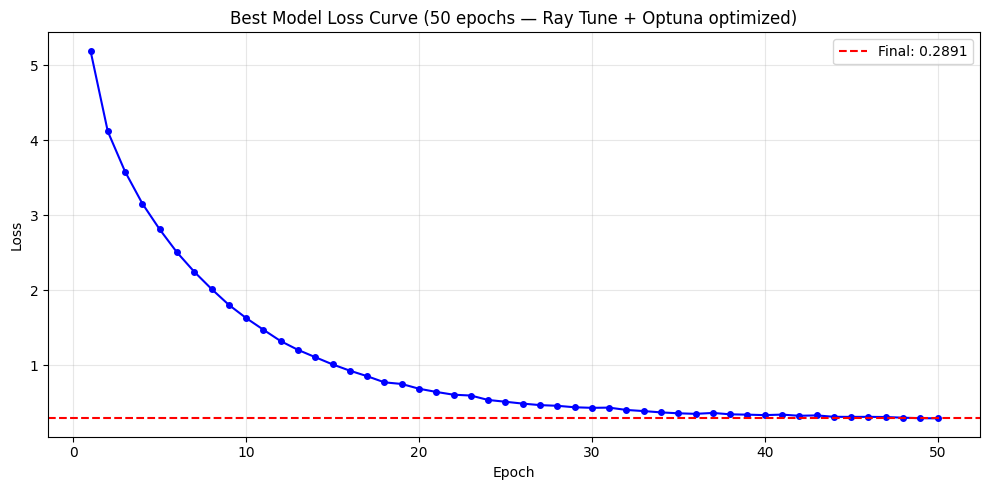

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
# CELL 25
import matplotlib.pyplot as plt
from google.colab import files

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(final_losses)+1), final_losses, 'b-o', markersize=4)
plt.axhline(y=final_losses[-1], color='red', linestyle='--', label=f"Final: {final_losses[-1]:.4f}")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title(f"Best Model Loss Curve ({EPOCHS} epochs — Ray Tune + Optuna optimized)")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Assignment4/loss_curve.png", dpi=150)
plt.show()

files.download(BEST_MODEL_PATH)

